# Example: single-basis neural quantum state tomography of a 1D TFIM ground state


This notebook demonstrates the reconstruction of a pure ground-state wavefunction from synthetic measurements in one computational basis.

Workflow:
1. Define a small transverse-field Ising model.
2. Obtain a reference ground state using NetKet VMC.
3. Generate synthetic single-basis measurement data.
4. Reconstruct the state using the `neural_qst` package.


In [8]:
%load_ext autoreload
%autoreload 2
import os, sys
print(os.getcwd())
sys.path.insert(0, "src")
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import netket as nk
import numpy as np

from netket.operator.spin import sigmax, sigmaz
from neural_qst import simple_gs_tomo
from neural_qst import simple_gs_tomo_control_variate
plt.rcParams["font.family"] = "Times New Roman"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
c:\Users\ecarrera\Downloads\qst_master


The first part follows the standard NetKet VMC workflow for the transverse-field Ising model.


No explicit MPI setup is required for this minimal example.


We use a small system with four spins and an RBM ansatz.


In [3]:
N_spins=4
hi=nk.hilbert.Spin(1/2,N=N_spins)
log_ans = nk.models.RBM(alpha=3)
para_ini = log_ans.init(jax.random.PRNGKey(0), hi.all_states())

C:\Users\ecarrera\AppData\Local\Temp\ipykernel_6976\524875954.py:2: UndeclaredSpinOderingWarning: 
You have not explicitly specified the spin ordering for the Hilbert space.
The default behaviour is currently `-1=↑, 1=↓`, but it will be changed 1st january 2025 to `1=↑, -1=↓`.

- To maintain the current behaviour in the future, specify `inverted_ordering=True` (this
    allows you to load NN parameters you have saved in the past)
- To opt-in today in the future default, specify `inverted_ordering=False` (so your code will
    work without changes in the future)

If you do not care about this warning, you can silence it by setting the environment variable
`NETKET_SPIN_ORDERING_WARNING=0` or by executing `nk.config.netket_spin_ordering_warning = False`

This warning will be shown once per day during interactive sessions, and always in scripts and MPI/SLURM jobs unless silenced.


-------------------------------------------------------
For more detailed informations, visit the following l

Define the one-dimensional transverse-field Ising Hamiltonian with periodic boundary conditions.


In [4]:
Gamma = -1
V=-1
H = sum([Gamma*sigmax(hi,i) for i in range(N_spins)])
H=H+sum([V*sigmaz(hi,i)*sigmaz(hi,(i+1)%N_spins) for i in range(N_spins)])

## Variational Montecarlo


In [5]:
log = nk.logging.RuntimeLog()
sampler = nk.sampler.MetropolisLocal(hi)
vstate = nk.vqs.MCState(sampler, log_ans, n_samples=1000)
vstate.init_parameters()

optimizer = nk.optimizer.Sgd(learning_rate=0.05)
gs = nk.driver.VMC(H, optimizer, variational_state=vstate)
gs.run(n_iter=500, out=log)


c:\Users\ecarrera\miniconda3\envs\nochane\lib\site-packages\netket\vqs\mc\mc_state\state.py:276: UserWarning: n_samples=1000 (1000 per device/MPI rank) does not divide n_chains=16, increased to 1008 (1008 per device/MPI rank)
  self.n_samples = n_samples


  0%|          | 0/500 [00:00<?, ?it/s]

(RuntimeLog():
  keys = ['acceptance', 'Energy'],)

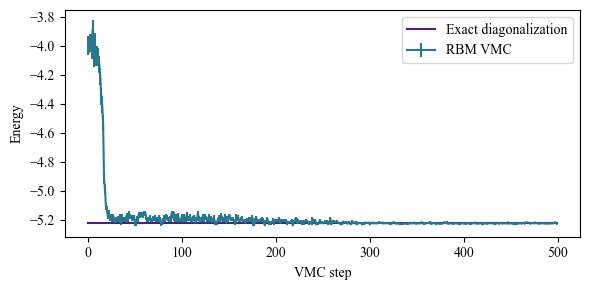

In [6]:
exact_energy = nk.exact.lanczos_ed(H)
data_rbm = log.data
exact_line = np.ones(500) * exact_energy

cmap = plt.cm.viridis
plt.figure(figsize=(6, 3))
plt.errorbar(
    data_rbm["Energy"].iters,
    data_rbm["Energy"].Mean,
    yerr=data_rbm["Energy"].Sigma,
    label="RBM VMC",
    color=cmap(0.4),
)
plt.plot(exact_line, label="Exact diagonalization", color=cmap(0.1))
plt.xlabel("VMC step")
plt.ylabel("Energy")
plt.legend()
plt.tight_layout()


## Quantum state tomography

We now generate a synthetic data set by sampling the VMC state exactly in the computational basis.


In [7]:
# Synthetic single-basis measurement data
vstate.sampler = nk.sampler.ExactSampler(hi, dtype=jnp.int8)
samples = vstate.sample(n_samples=int(1e5))

data_states, data_counts = jnp.unique(
    samples.reshape(-1, N_spins),
    axis=0,
    return_counts=True,
)

# Reference wavefunction used only to monitor the reconstruction infidelity.
log_psi_reference = vstate.log_value(hi.all_states())
psi_reference = jnp.exp(log_psi_reference)
psi_reference = psi_reference / jnp.sqrt(jnp.sum(jnp.abs(psi_reference) ** 2))


Run neural QST using the control-variate training loop. The returned object contains the optimized parameters and the diagnostic histories.


In [9]:
result = simple_gs_tomo_control_variate(
    keyini=jax.random.PRNGKey(85),
    H=H,
    log_ans=log_ans,
    params=para_ini,
    n_iter=500,
    batch_size=100,
    freq_data_set=data_counts,
    freq_space=data_states,
    N=N_spins,
    samples_in=1000,
    hi=hi,
    learn=0.01,
    synthe_wave=psi_reference,
    start_save=0,
    control_rate=30,
    mu=0.8,
)

params_qst = result.parameters
energy_history = result.history.energy
kl_history = result.history.kl_divergence
infidelity_history = result.history.infidelity


c:\Users\ecarrera\miniconda3\envs\nochane\lib\site-packages\netket\sampler\metropolis.py:278: FutureWarning: Specifying `n_sweeps` when constructing sampler is deprecated. Please use `sweep_size` instead.
  warn_deprecation(


  0%|          | 0/500 [00:00<?, ?it/s]

c:\Users\ecarrera\miniconda3\envs\nochane\lib\site-packages\netket\sampler\metropolis.py:278: FutureWarning: Specifying `n_sweeps` when constructing sampler is deprecated. Please use `sweep_size` instead.
  warn_deprecation(
c:\Users\ecarrera\miniconda3\envs\nochane\lib\site-packages\netket\sampler\metropolis.py:278: FutureWarning: Specifying `n_sweeps` when constructing sampler is deprecated. Please use `sweep_size` instead.
  warn_deprecation(
c:\Users\ecarrera\miniconda3\envs\nochane\lib\site-packages\netket\sampler\metropolis.py:278: FutureWarning: Specifying `n_sweeps` when constructing sampler is deprecated. Please use `sweep_size` instead.
  warn_deprecation(
c:\Users\ecarrera\miniconda3\envs\nochane\lib\site-packages\netket\sampler\metropolis.py:278: FutureWarning: Specifying `n_sweeps` when constructing sampler is deprecated. Please use `sweep_size` instead.
  warn_deprecation(
c:\Users\ecarrera\miniconda3\envs\nochane\lib\site-packages\netket\sampler\metropolis.py:278: Future

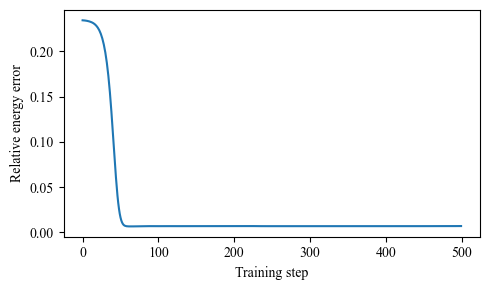

In [10]:
plt.figure(figsize=(5, 3))
plt.plot(jnp.abs((energy_history - exact_energy) / exact_energy))
plt.xlabel("Training step")
plt.ylabel("Relative energy error")
plt.tight_layout()


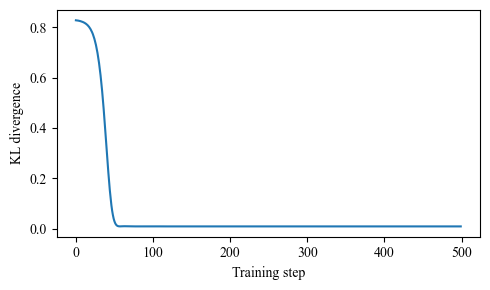

In [11]:
plt.figure(figsize=(5, 3))
plt.plot(kl_history)
plt.xlabel("Training step")
plt.ylabel("KL divergence")
plt.tight_layout()


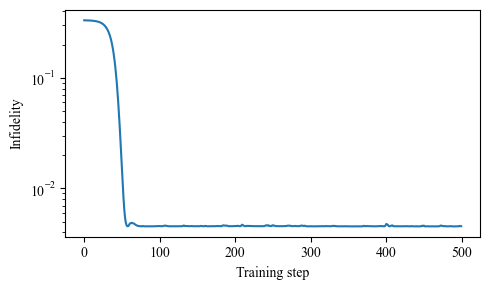

In [12]:
plt.figure(figsize=(5, 3))
plt.plot(infidelity_history)
plt.xlabel("Training step")
plt.ylabel("Infidelity")
plt.yscale("log")
plt.tight_layout()


In [13]:
log_psi_qst = log_ans.apply(params_qst, hi.all_states())
psi_qst = jnp.exp(log_psi_qst)
psi_qst = psi_qst / jnp.sqrt(jnp.sum(jnp.abs(psi_qst) ** 2))


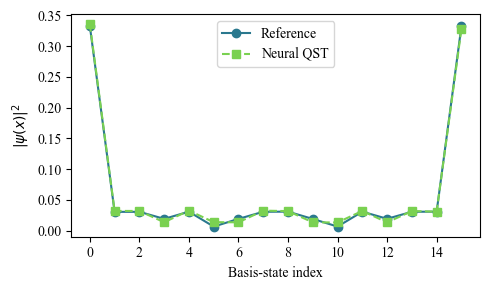

In [14]:
plt.figure(figsize=(5, 3))
plt.plot(jnp.abs(psi_reference) ** 2, "o-", label="Reference", color=cmap(0.4))
plt.plot(jnp.abs(psi_qst) ** 2, "s--", label="Neural QST", color=cmap(0.8))
plt.xlabel("Basis-state index")
plt.ylabel(r"$|\psi(x)|^2$")
plt.legend()
plt.tight_layout()


In [ ]:
final_infidelity = 1.0 - jnp.abs(jnp.vdot(psi_reference, psi_qst)) ** 2
print(f"Final infidelity: {float(final_infidelity):.3e}")
